# Feature Engineering: Distance to Roads

## Objective

In this notebook, I create a feature that captures human interaction by calculating the distance from each location to the nearest major road.

This feature is used as a proxy for how accessible an area is, which can influence wildfire risk.



## Step 1: Load Road Network Data

I load U.S. primary road shapefile data using GeoPandas.

This dataset contains major road networks across the United States, which will later be used to calculate proximity to human infrastructure.


In [12]:
import geopandas as gpd

roads = gpd.read_file(
    "/Users/malikibrahimalikhan/Downloads/tl_2023_us_primaryroads/tl_2023_us_primaryroads.shp"
)


In [13]:

print(roads.shape)
print(roads.crs)


(17458, 5)
EPSG:4269



## Step 2: Extract Colorado Roads

To focus only on relevant data:

- I load U.S. state boundaries
- Select only Colorado
- Reproject the road data to match the state dataset
- Clip the roads to Colorado

This ensures that only roads within Colorado are used.


In [15]:

states = gpd.read_file(
    "/Users/malikibrahimalikhan/Downloads/tl_2023_us_state/tl_2023_us_state.shp"
)

colorado = states[states["NAME"] == "Colorado"]
roads = roads.to_crs(colorado.crs)
roads_co = gpd.clip(roads, colorado)


## Step 3: Create a Temporary Spatial Grid

Since I don’t yet have a full grid structure, I generate random points within Colorado to simulate grid locations.

Each point represents a location where wildfire risk features will later be computed.

This is used as a placeholder for testing the distance calculations.


In [16]:

import geopandas as gpd

# Select Colorado boundary
colorado = states[states["NAME"] == "Colorado"]

# Reproject roads to match states CRS
roads = roads.to_crs(colorado.crs)

# Clip roads to Colorado
roads_co = gpd.clip(roads, colorado)

print("Roads in Colorado:", roads_co.shape)


Roads in Colorado: (360, 5)


## Step 4: Calculate Distance to Nearest Road (Initial)

For each grid point, I compute the distance to the closest road.

However, this step initially uses a geographic coordinate system (latitude/longitude), which produces incorrect distance values.


In [18]:
from shapely.geometry import Point
import numpy as np

# Create random points inside Colorado (temporary stand-in grid)
minx, miny, maxx, maxy = colorado.total_bounds

points = [
    Point(
        np.random.uniform(minx, maxx),
        np.random.uniform(miny, maxy)
    )
    for _ in range(500)
]

grid = gpd.GeoDataFrame(geometry=points, crs=colorado.crs)

print("Temporary grid created:", grid.shape)

Temporary grid created: (500, 1)



## Important Note: Coordinate System Issue

Distance calculations should not be performed in a geographic CRS (like lat/lon).

This produces incorrect results because:

- Units are in degrees instead of meters
- Distances are distorted

To fix this, the data must be reprojected into a projected CRS.


In [19]:
# Ensure CRS match
grid = grid.to_crs(roads_co.crs)

# Compute distance to nearest road (meters)
grid["distance_to_road_m"] = grid.geometry.apply(
    lambda p: roads_co.distance(p).min()
)

# Convert to kilometers
grid["distance_to_road_km"] = grid["distance_to_road_m"] / 1000

grid[["distance_to_road_km"]].describe()

/var/folders/b_/lqk5v6r95zs00836sfhn9pxw0000gn/T/ipykernel_88675/346500858.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda p: roads_co.distance(p).min()


,distance_to_road_km
count,5.000000e+02
mean,6.806837e-04
std,5.314184e-04
min,9.852144e-08
25%,2.415167e-04
50%,5.428747e-04
75%,1.041258e-03
max,2.261266e-03


## Step 5: Reproject Data to UTM

I convert both the road network and grid points to a projected CRS:


In [21]:
#Reproject everything to UTM Zone 13N (meters)
projected_crs = "EPSG:26913"

roads_co_proj = roads_co.to_crs(projected_crs)
grid_proj = grid.to_crs(projected_crs)


## Step 6: Compute Accurate Distance to Roads

After fixing the coordinate system:

- Distance is computed in meters
- Then converted to kilometers

This produces realistic distance values that can be used in the model.


In [22]:

# Distance in meters
grid_proj["distance_to_road_m"] = grid_proj.geometry.apply(
    lambda p: roads_co_proj.distance(p).min()
)

# Convert to kilometers
grid_proj["distance_to_road_km"] = grid_proj["distance_to_road_m"] / 1000

grid_proj["distance_to_road_km"].describe()


count    500.000000
mean      69.773943
std       54.635832
min        0.009722
25%       25.685966
50%       56.706004
75%      106.850926
max      234.612973
Name: distance_to_road_km, dtype: float64


## Step 7: Save Processed Data

The results are saved to a GeoPackage file for spatial use.

This preserves geometry and distance values for future analysis.


In [27]:
import os

In [28]:

output_path = os.path.expanduser(
    "~/Downloads/grid_with_distance_to_road.gpkg"
)

grid_proj.to_file(output_path, driver="GPKG")



## Step 8: Visualize Distance to Roads

I create a map showing how distance varies across locations.

This helps validate:
- Whether distances look reasonable
- Whether spatial patterns make sense


<Axes: >

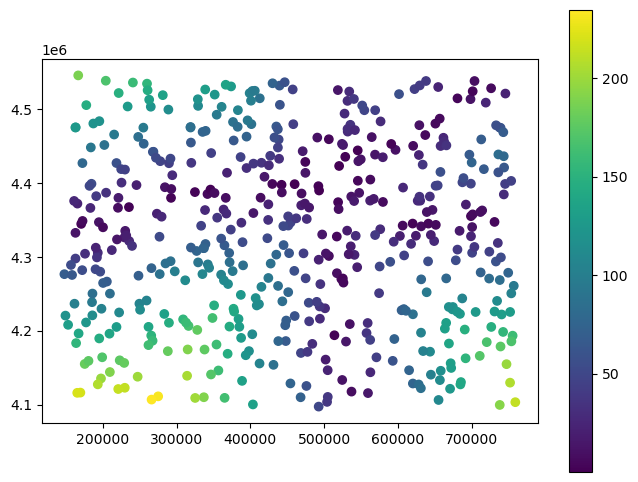

In [24]:

grid_proj.plot(
    column="distance_to_road_km",
    legend=True,
    figsize=(8, 6)
)


In [ ]:

output_path = os.path.expanduser(
    "~/Downloads/grid_with_distance_to_road.gpkg"
)

grid_proj.to_file(output_path, driver="GPKG")



## Step 9: Convert Back to Latitude and Longitude

After computing distance in projected coordinates, I convert the data back to latitude/longitude.

This allows it to be combined with other datasets that use geographic coordinates.


In [30]:

grid_ll = grid_proj.to_crs("EPSG:4326")

grid_ll["lat"] = grid_ll.geometry.y
grid_ll["lon"] = grid_ll.geometry.x

road_df = grid_ll[["lat", "lon", "distance_to_road_km"]]

road_df.head()


,lat,lon,distance_to_road_km
0,39.390925,-102.514421,10.674708
1,39.721083,-102.681393,47.462635
2,37.842334,-103.919965,72.660478
3,39.995071,-105.995731,34.508178
4,39.479343,-105.362131,19.650624



# Step 10: Create Final Feature Table

I extract:

- Latitude
- Longitude
- Distance to the nearest road (km)

This dataset will be used as an input feature for the wildfire prediction model.


## Step 11: Save Feature Data

The final dataset is saved in Parquet format:

- Efficient storage
- Fast loading for modeling

This completes the road distance feature engineering step.


In [31]:

road_df.to_parquet(
    "~/Downloads/distance_to_road.parquet",
    index=False
)


## Conclusion

In this notebook, I created a feature representing distance to the nearest major road.

Key takeaways:

- Road proximity is used as a proxy for human activity
- Proper coordinate systems are critical for accurate distance calculations
- The final dataset integrates spatial information into the wildfire model

This feature helps explain where wildfire risk may be influenced by human access and activity.
